# Tsukamoto Fuzzy Reasoning Visualization and Sensitivity Analysis

This notebook is used to visualize the Tsukamoto membership functions and explain how the fuzzy reasoning component works in the hybrid sentiment analysis framework.

The final Tsukamoto parameters used in the experiment were selected through validation-based tuning.  
Therefore, this notebook is mainly used for:

1. Visualizing the final tuned membership functions  
2. Demonstrating how Tsukamoto inference works on sample probability inputs  
3. Exploring parameter sensitivity through slider-based interaction  

**Note:**  
The sliders in this notebook are provided for interpretability demonstration and exploratory analysis only.  
The official experimental parameters were determined using the validation set, not by manual adjustment in this notebook.

In [1]:
import sys

PROJECT_ROOT = r"I:\MasterFyp\NLP_HYBRID_SENTIMENTAL"
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

print("PROJECT_ROOT =", PROJECT_ROOT)

PROJECT_ROOT = I:\MasterFyp\NLP_HYBRID_SENTIMENTAL


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

from src.fuzzy_system import (
    get_default_params,
    low_membership,
    medium_membership,
    high_membership,
    infer_sentiment
)

## Final Validation-Tuned Tsukamoto Parameters

The parameter values below were selected through validation-based tuning and are treated as the final experimental Tsukamoto parameters used in the project.

In [3]:
best_params = get_default_params()

for var in ["neg", "neu", "pos"]:
    best_params[var]["low"]["a"] = 0.30
    best_params[var]["low"]["b"] = 0.48

    best_params[var]["medium"]["a"] = 0.30
    best_params[var]["medium"]["b"] = 0.50
    best_params[var]["medium"]["c"] = 0.75

    best_params[var]["high"]["a"] = 0.45
    best_params[var]["high"]["b"] = 0.68

print("Current parameter setting: validation-tuned Tsukamoto parameters")
best_params

Current parameter setting: validation-tuned Tsukamoto parameters


{'neg': {'low': {'a': 0.3, 'b': 0.48},
  'medium': {'a': 0.3, 'b': 0.5, 'c': 0.75},
  'high': {'a': 0.45, 'b': 0.68}},
 'neu': {'low': {'a': 0.3, 'b': 0.48},
  'medium': {'a': 0.3, 'b': 0.5, 'c': 0.75},
  'high': {'a': 0.45, 'b': 0.68}},
 'pos': {'low': {'a': 0.3, 'b': 0.48},
  'medium': {'a': 0.3, 'b': 0.5, 'c': 0.75},
  'high': {'a': 0.45, 'b': 0.68}},
 'output': {'negative': {'z_min': 0.0, 'z_max': 0.35},
  'neutral_low': {'z_min': 0.35, 'z_max': 0.5},
  'neutral_high': {'z_min': 0.5, 'z_max': 0.65},
  'positive': {'z_min': 0.65, 'z_max': 1.0}}}

## Visualization of Final Membership Functions

The plots below show the final tuned membership functions for negative, neutral, and positive probability inputs.

In [4]:
def plot_three_variable_memberships(neg_params, neu_params, pos_params):
    x = np.linspace(0, 1, 500)

    fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))

    variable_configs = [
        ("Negative Probability", neg_params, axes[0]),
        ("Neutral Probability", neu_params, axes[1]),
        ("Positive Probability", pos_params, axes[2]),
    ]

    for title, params, ax in variable_configs:
        low_vals = [low_membership(v, params["low"]["a"], params["low"]["b"]) for v in x]
        med_vals = [
            medium_membership(v, params["medium"]["a"], params["medium"]["b"], params["medium"]["c"])
            for v in x
        ]
        high_vals = [high_membership(v, params["high"]["a"], params["high"]["b"]) for v in x]

        ax.plot(x, low_vals, label="Low")
        ax.plot(x, med_vals, label="Medium")
        ax.plot(x, high_vals, label="High")

        ax.set_title(title, fontsize=11)
        ax.set_xlabel("Probability", fontsize=9)
        ax.set_ylabel("Membership Degree", fontsize=9)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1.05)
        ax.grid(True)
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

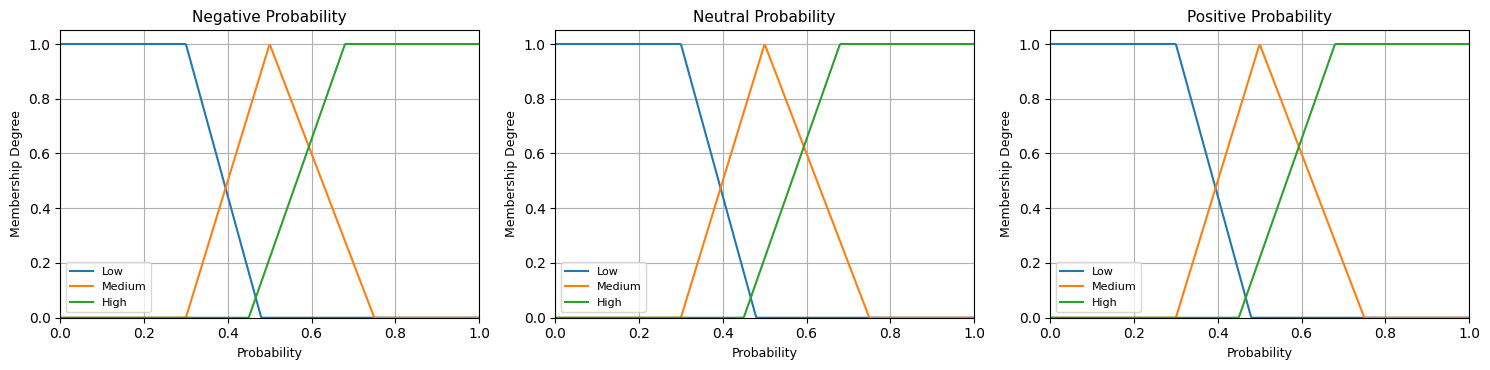

In [5]:
plot_three_variable_memberships(
    neg_params=best_params["neg"],
    neu_params=best_params["neu"],
    pos_params=best_params["pos"]
)

## Tsukamoto Inference Demonstration with Final Parameters

This section demonstrates how the final tuned Tsukamoto system processes a given set of sentiment probabilities and produces:
- final score
- final label
- top fired rules

In [6]:
def show_tsukamoto_inference_with_fixed_params(p_neg, p_neu, p_pos, params):
    score, label, fired_rules = infer_sentiment(
        p_neg=p_neg,
        p_neu=p_neu,
        p_pos=p_pos,
        params=params
    )

    print("=== Tsukamoto Inference Result ===")
    print(f"Input probabilities: p_neg={p_neg:.3f}, p_neu={p_neu:.3f}, p_pos={p_pos:.3f}")
    print(f"Final score: {score:.4f}")
    print(f"Final label: {label}")

    print("\nTop fired rules:")
    if fired_rules:
        sorted_rules = sorted(fired_rules, key=lambda x: x["alpha"], reverse=True)
        for rule in sorted_rules[:5]:
            print(
                f"- {rule['rule']} | alpha={rule['alpha']:.4f} | "
                f"z={rule['z']:.4f} | output={rule['output']}"
            )
    else:
        print("- No rules fired, fallback was used.")

In [7]:
show_tsukamoto_inference_with_fixed_params(
    p_neg=0.30,
    p_neu=0.50,
    p_pos=0.20,
    params=best_params
)

=== Tsukamoto Inference Result ===
Input probabilities: p_neg=0.300, p_neu=0.500, p_pos=0.200
Final score: 0.4790
Final label: neutral

Top fired rules:
- IF neg is low AND neu is medium AND pos is low THEN neutral_low | alpha=1.0000 | z=0.5000 | output=neutral_low
- IF neg is low AND neu is high AND pos is low THEN neutral_low | alpha=0.2174 | z=0.3826 | output=neutral_low


## Exploratory Sensitivity Analysis

The sliders below are provided for exploratory analysis only.  
They do not replace the validation-based tuning process.  
Their purpose is to help visualize how changes in membership boundaries affect:
- the membership curves
- the Tsukamoto score
- the final sentiment label
- the fired rules

In [8]:
def plot_memberships(low_a, low_b, med_a, med_b, med_c, high_a, high_b, title="Membership Functions"):
    x = np.linspace(0, 1, 500)

    low_vals = [low_membership(v, low_a, low_b) for v in x]
    med_vals = [medium_membership(v, med_a, med_b, med_c) for v in x]
    high_vals = [high_membership(v, high_a, high_b) for v in x]

    plt.figure(figsize=(6, 3.5))
    plt.plot(x, low_vals, label="Low")
    plt.plot(x, med_vals, label="Medium")
    plt.plot(x, high_vals, label="High")
    plt.title(title, fontsize=12)
    plt.xlabel("Probability", fontsize=10)
    plt.ylabel("Membership Degree", fontsize=10)
    plt.xlim(0, 1)
    plt.ylim(0, 1.05)
    plt.grid(True)
    plt.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

In [9]:
def build_params_from_sliders(low_a, low_b, med_a, med_b, med_c, high_a, high_b):
    params = get_default_params()

    for var in ["neg", "neu", "pos"]:
        params[var]["low"]["a"] = low_a
        params[var]["low"]["b"] = low_b

        params[var]["medium"]["a"] = med_a
        params[var]["medium"]["b"] = med_b
        params[var]["medium"]["c"] = med_c

        params[var]["high"]["a"] = high_a
        params[var]["high"]["b"] = high_b

    return params

In [10]:
def show_tsukamoto_inference(
    low_a, low_b, med_a, med_b, med_c, high_a, high_b,
    p_neg, p_neu, p_pos
):
    params = build_params_from_sliders(low_a, low_b, med_a, med_b, med_c, high_a, high_b)

    score, label, fired_rules = infer_sentiment(
        p_neg=p_neg,
        p_neu=p_neu,
        p_pos=p_pos,
        params=params
    )

    print("=== Tsukamoto Inference Result ===")
    print(f"Input probabilities: p_neg={p_neg:.3f}, p_neu={p_neu:.3f}, p_pos={p_pos:.3f}")
    print(f"Final score: {score:.4f}")
    print(f"Final label: {label}")

    print("\nTop fired rules:")
    if fired_rules:
        sorted_rules = sorted(fired_rules, key=lambda x: x["alpha"], reverse=True)
        for rule in sorted_rules[:5]:
            print(
                f"- {rule['rule']} | alpha={rule['alpha']:.4f} | "
                f"z={rule['z']:.4f} | output={rule['output']}"
            )
    else:
        print("- No rules fired, fallback was used.")

In [11]:
def plot_and_infer(
    low_a, low_b, med_a, med_b, med_c, high_a, high_b,
    p_neg, p_neu, p_pos
):
    plot_memberships(
        low_a=low_a,
        low_b=low_b,
        med_a=med_a,
        med_b=med_b,
        med_c=med_c,
        high_a=high_a,
        high_b=high_b,
        title="Tsukamoto Membership Functions"
    )

    show_tsukamoto_inference(
        low_a=low_a,
        low_b=low_b,
        med_a=med_a,
        med_b=med_b,
        med_c=med_c,
        high_a=high_a,
        high_b=high_b,
        p_neg=p_neg,
        p_neu=p_neu,
        p_pos=p_pos
    )

In [ ]:
style = {"description_width": "60px"}
layout = widgets.Layout(width="350px")

low_a_slider = widgets.FloatSlider(
    value=0.30, min=0.0, max=0.8, step=0.01,
    description="low_a", style=style, layout=layout
)
low_b_slider = widgets.FloatSlider(
    value=0.48, min=0.1, max=1.0, step=0.01,
    description="low_b", style=style, layout=layout
)

med_a_slider = widgets.FloatSlider(
    value=0.30, min=0.0, max=0.8, step=0.01,
    description="med_a", style=style, layout=layout
)
med_b_slider = widgets.FloatSlider(
    value=0.50, min=0.1, max=0.9, step=0.01,
    description="med_b", style=style, layout=layout
)
med_c_slider = widgets.FloatSlider(
    value=0.75, min=0.2, max=1.0, step=0.01,
    description="med_c", style=style, layout=layout
)

high_a_slider = widgets.FloatSlider(
    value=0.45, min=0.0, max=0.9, step=0.01,
    description="high_a", style=style, layout=layout
)
high_b_slider = widgets.FloatSlider(
    value=0.68, min=0.1, max=1.0, step=0.01,
    description="high_b", style=style, layout=layout
)

p_neg_slider = widgets.FloatSlider(
    value=0.30, min=0.0, max=1.0, step=0.01,
    description="p_neg", style=style, layout=layout
)
p_neu_slider = widgets.FloatSlider(
    value=0.50, min=0.0, max=1.0, step=0.01,
    description="p_neu", style=style, layout=layout
)
p_pos_slider = widgets.FloatSlider(
    value=0.20, min=0.0, max=1.0, step=0.01,
    description="p_pos", style=style, layout=layout
)

In [ ]:
ui = widgets.VBox([
    low_a_slider, low_b_slider,
    med_a_slider, med_b_slider, med_c_slider,
    high_a_slider, high_b_slider,
    p_neg_slider, p_neu_slider, p_pos_slider
])

out = widgets.interactive_output(
    plot_and_infer,
    {
        "low_a": low_a_slider,
        "low_b": low_b_slider,
        "med_a": med_a_slider,
        "med_b": med_b_slider,
        "med_c": med_c_slider,
        "high_a": high_a_slider,
        "high_b": high_b_slider,
        "p_neg": p_neg_slider,
        "p_neu": p_neu_slider,
        "p_pos": p_pos_slider,
    }
)

display(ui, out)

Output()

: 

## Notes for Interpretation

- The final experimental Tsukamoto parameters were selected through validation-based tuning.
- The interactive sliders above are provided for visualization and sensitivity analysis only.
- The formal model evaluation reported in the project was based on the fixed tuned parameters, not on manually adjusted slider values.